In [2]:
!pip install spite -q
import numpy as np
import spite as sp
import matplotlib.pyplot as plt

# Quarter-wave matching network

<Axes: title={'center': 'Magnitude Response of $S_{11}$ (dB)'}, xlabel='Frequency (GHz)', ylabel='|$S_{11}$| (dB)'>

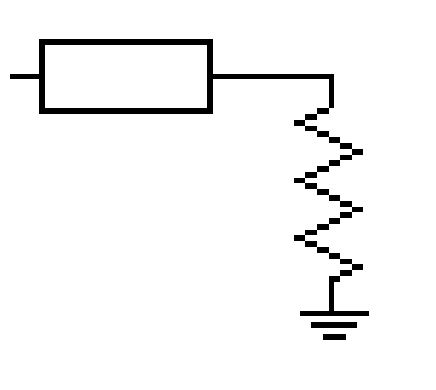

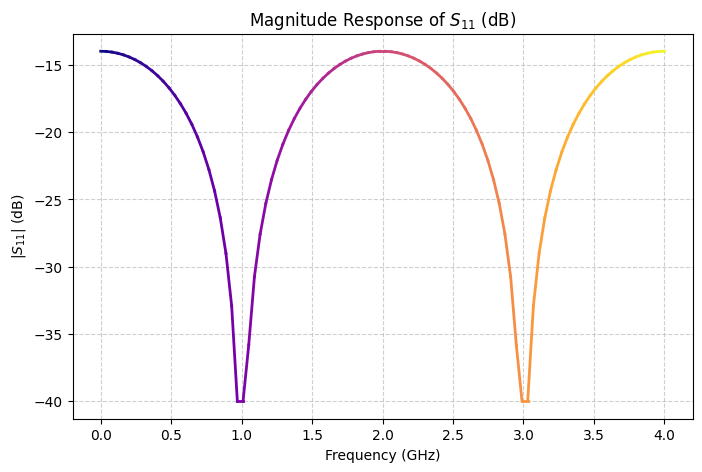

In [3]:
f = np.linspace(0.1, 4e9, 100)  # frequency sweep

# Zc = sqrt(Z0*R) is the quarter-wave matching condition
matching_network = (
    sp.net2p_tline_series(f=f, f0=1e9, EL_deg=90, Zc=np.sqrt(50 * 75))
    @ sp.net1p_R(f=f, R=75)  # terminates the network with a 75-ohm load
)

matching_network.plot_schematic()  # horizontal stack of SYM2P_TLINE_SERIES + SYM1P_R
matching_network.plot_dB()  # S11 in dB

# RLGC ladder

<Axes: title={'center': '$S_{11}$ [Impedance View]'}>

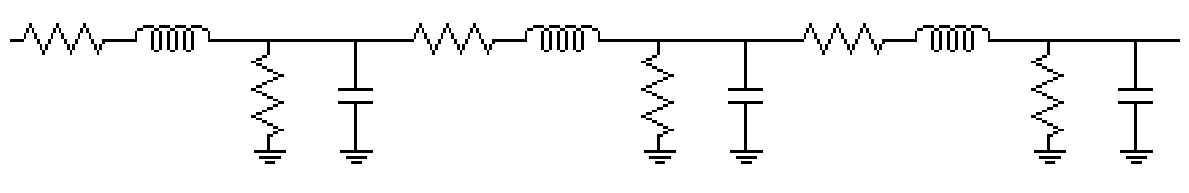

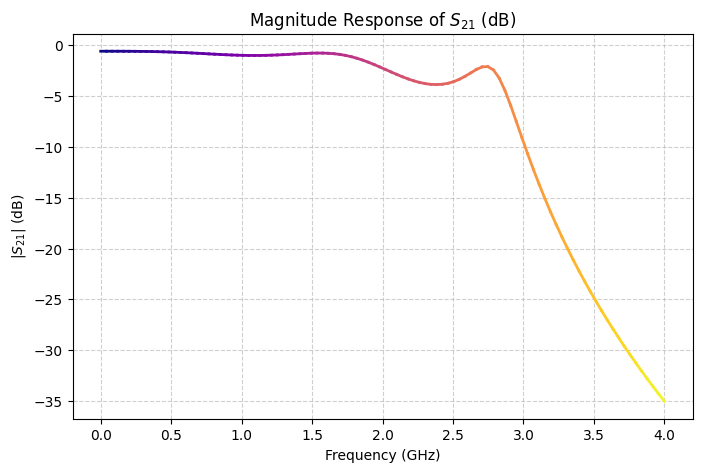

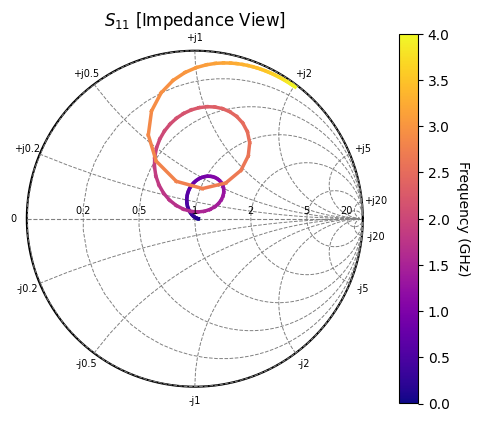

In [4]:
f = np.linspace(0.1, 4e9, 100)  # frequency sweep
R, L, G, C = 1.5, 5e-9, 3e-4, 2e-12  # R, L, G, C values of one section

ladder = sp.net2p_RLGC(f, R, L, G, C) ** 3  # ** repeats the section 3 times

ladder.plot_schematic()
ladder.plot_dB(port_indices=(2, 1))  # S21 in dB
ladder.plot_smith()  # color gradient encodes frequency

# Lumped-element low-pass filter

-3.0126786911314083


<Axes: title={'center': 'S-Parameters [Admittance View]'}>

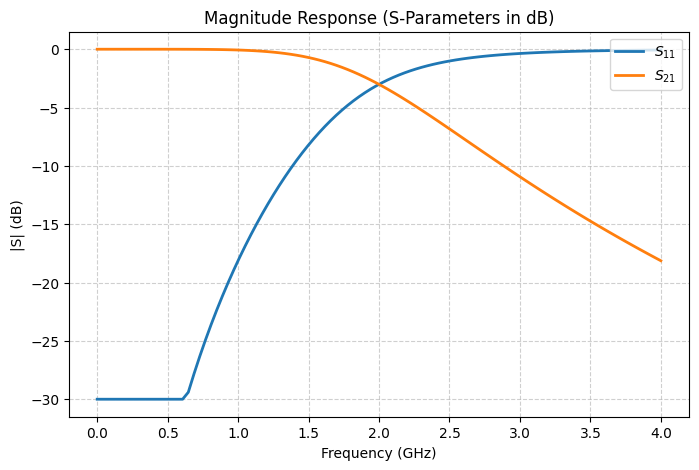

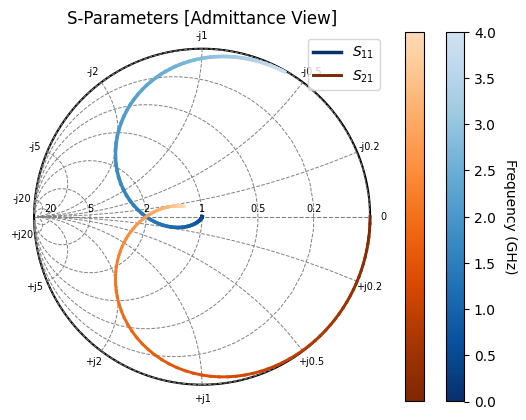

In [5]:
f = np.linspace(0.1, 4e9, 100)  # frequency sweep

filter = (
    sp.net2p_L_series(f, 3.9785e-9)
    @ sp.net2p_C_shunt(f, 3.184e-12)
    @ sp.net2p_L_series(f, 3.9785e-9)
)

S11_at_2GHz = filter.sample(2e9, param="S", port_indices=(1, 1))
print(20 * np.log10(np.abs(S11_at_2GHz)))  # -3.0127 dB

filter.plot_dB(floor=-30, port_indices=[(1, 1), (2, 1)])
filter.plot_smith(port_indices=[(1, 1), (2, 1)], chart_type="Y")  # Admittance charts are available as well

# Touchstone Import

Saving antenita.s1p to antenita.s1p


Text(0.5, 1.0, 'Magnitude Response after Time-domain Gating')

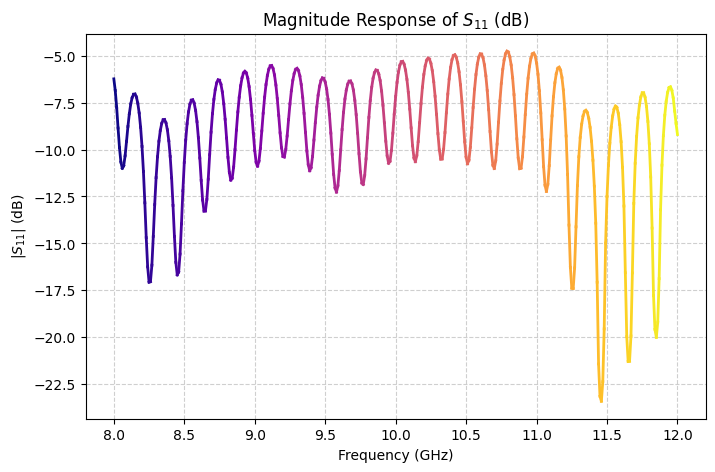

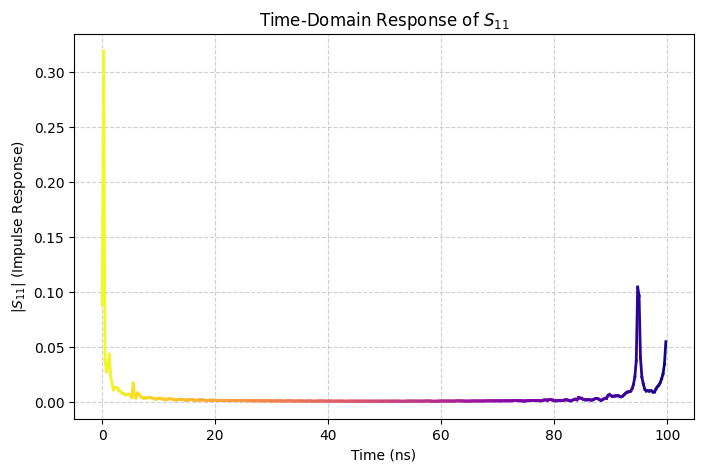

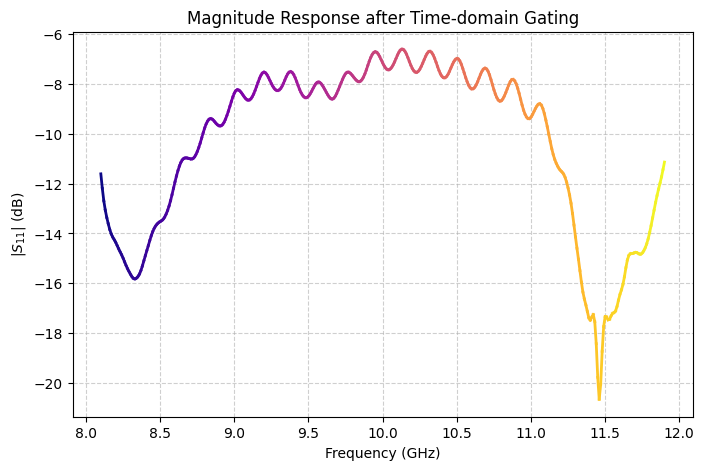

In [7]:
from google.colab import files
import os

os.makedirs("/content/touchstone", exist_ok=True)  # folder named touchstone
uploaded = files.upload()  # opens Colab's file picker
ts_filename = list(uploaded.keys())[0]  # grab the filename
TOUCHSTONE_PATH = list(uploaded.keys())[0]  # placeholder

ext = os.path.splitext(ts_filename)[1].lower()  # extract the file extension
TOUCHSTONE_PATH = f"/content/touchstone/uploaded{ext}"  # standardize the filename
os.rename(f"/content/{ts_filename}", TOUCHSTONE_PATH)  # move the file into our touchstone folder


antenna = sp.read_touchstone(TOUCHSTONE_PATH)
antenna.schematic = sp.SYM1P_ANTENNA  # antenna symbol as the schematic
antenna.plot_dB()
antenna.plot_time_domain()
antenna_gated = antenna.gate(0, 20e-9)  # cut out anything after 20ns
ax = antenna_gated.plot_dB()  # plot after time-domain gating
ax.set_title("Magnitude Response after Time-domain Gating")